# Task 5 — Python Analytics Notebook
## Cell 1 — Import Libraries

In [2]:
!pip install sqlalchemy

   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---- ----------------------------------- 0.3/2.1 MB ? eta -:--:--
   ---- ----------------------------------- 0.3/2.1 MB ? eta -:--:--
   ---- ----------------------------------- 0.3/2.1 MB ? eta -:--:--
   --------- ------------------------------ 0.5/2.1 MB 508.0 kB/s eta 0:00:04
   --------- ------------------------------ 0.5/2.1 MB 508.0 kB/s eta 0:00:04
   -------------- ------------------------- 0.8/2.1 MB 516.0 kB/s eta 0:00:03
   -------------- ------------------------- 0.8/2.1 MB 516.0 kB/s eta 0:00:03
   ------------------- -------------------- 1.0/2.1 MB 535.4 kB/s eta 0:00:03
   ------------------- -------------------- 1.0/2.1 MB 535.4 kB/s eta 0:00:03
   ------------------- -------------------- 1.0/2.1 MB 535.4 kB/s eta 0:00:03
   ------------------------ ------------

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sqlalchemy import create_engine

## Cell 2 — Connect PostgreSQL

In [6]:
import sys
!{sys.executable} -m pip install psycopg2-binary

In [7]:
username = "postgres"
password = "postgres2026"
host = "localhost"
port = "5432"
database = "AdventureWorks"


engine = create_engine(
    f"postgresql://{username}:{password}@{host}:{port}/{database}"
)

print("Connected successfully")

Connected successfully


## Cell 3 — Load Analytical Datasets Only

In [8]:
monthly_revenue = pd.read_sql(
"""
SELECT *
FROM analytics.monthly_revenue
""",
engine
)


sales_growth = pd.read_sql(
"""
SELECT *
FROM analytics.sales_growth
""",
engine
)


territory_sales = pd.read_sql(
"""
SELECT *
FROM analytics.territory_metrics
""",
engine
)


customer_segments = pd.read_sql(
"""
SELECT *
FROM analytics.customer_segments
""",
engine
)


category_performance = pd.read_sql(
"""
SELECT *
FROM analytics.category_performance
""",
engine
)


product_performance = pd.read_sql(
"""
SELECT *
FROM analytics.product_rankings
""",
engine
)


employee_performance = pd.read_sql(
"""
SELECT *
FROM analytics.employee_rankings
""",
engine
)


inventory_status = pd.read_sql(
"""
SELECT *
FROM analytics.inventory_metrics
""",
engine
)

In [21]:
import os

output_dir = "charts"
os.makedirs(output_dir, exist_ok=True)

## Visualization 1 — Revenue Trend

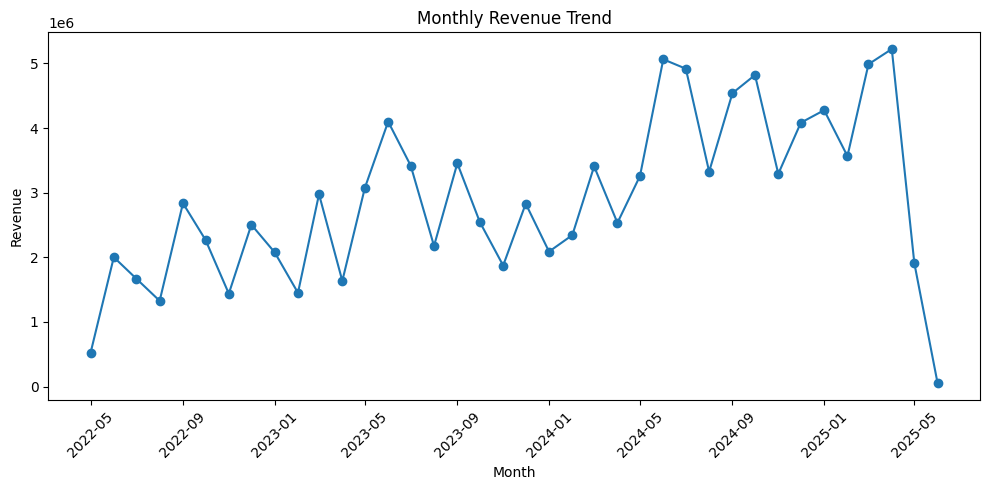

In [22]:
plt.figure(figsize=(10,5))
plt.plot(monthly_revenue["sales_month"], monthly_revenue["revenue"], marker="o")
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f"{output_dir}/01_revenue_trend.png", dpi=300, bbox_inches="tight")
plt.show()

### Business Insight:
Business Insight:
Revenue shows a clear overall upward trend from roughly $0.5M (mid-2022) to peaks near $5.2M (early 2025), with a recurring saw-tooth pattern suggesting seasonal or quarterly cycles rather than smooth growth. However, the final data point drops sharply to near $0 in 2025-05 — this is almost certainly an artifact of incomplete data for the most recent month (the month is still "in progress" or the extract was pulled mid-month) rather than an actual revenue collapse. 

### Recommendation: 
exclude or flag the last partial month when reporting trend/growth figures, or the business could misread a data artifact as a crisis.

## Visualization 2 — Sales Growth

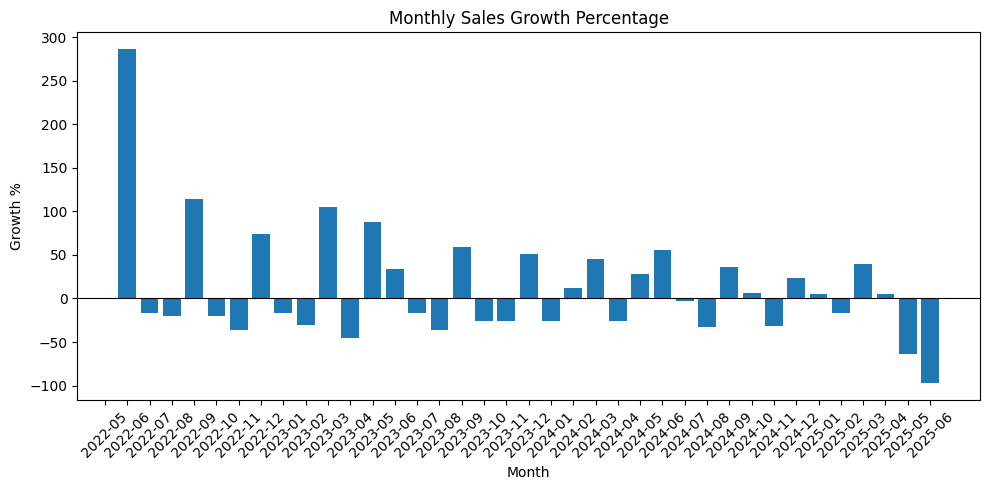

In [31]:
plt.figure(figsize=(10,5))

x_labels = sales_growth["sales_month"].dt.strftime("%Y-%m")

plt.bar(x_labels, sales_growth["growth_percent"])
plt.title("Monthly Sales Growth Percentage")
plt.xlabel("Month")
plt.ylabel("Growth %")
plt.xticks(rotation=45)
plt.axhline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.savefig(f"{output_dir}/02_sales_growth.png", dpi=300, bbox_inches="tight")
plt.show()

### Business Insight:
Monthly growth is highly volatile, swinging from roughly +290% to −100% within the observed period, rather than showing steady growth. This suggests demand is driven by irregular large orders or seasonal spikes rather than consistent sales momentum — management should investigate whether specific promotions, contracts, or customers are causing these spikes before relying on any single month as a trend indicator.

## Visualization 3 — Sales by Territory

<Figure size 1000x500 with 0 Axes>

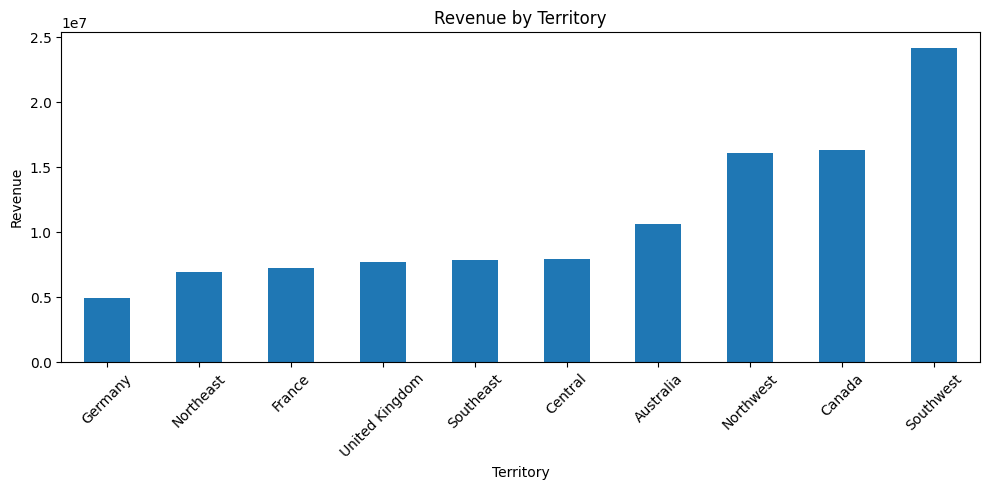

In [24]:
plt.figure(figsize=(10,5))
territory_sales.sort_values("territory_sales").plot(
    x="territory", y="territory_sales", kind="bar", figsize=(10,5), legend=False
)
plt.title("Revenue by Territory")
plt.xlabel("Territory")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f"{output_dir}/03_sales_by_territory.png", dpi=300, bbox_inches="tight")
plt.show()

### Business Insight:
Southwest is the clear leader at roughly $24M, nearly 5x Germany's ~$5M, the lowest-performing territory. Canada and Northwest form a strong second tier (~$16M each), while Germany, Northeast, and France cluster at the bottom (~$5–7M). This is a meaningful geographic concentration: the top 3 territories (Southwest, Canada, Northwest) likely account for well over half of total territory revenue. Recommendation: investigate what's driving Southwest's outperformance (pricing, team size, market size) to see if it's replicable in underperforming European territories like Germany and France, rather than assuming those markets are simply smaller.

## Visualization 4 — Customer Segments

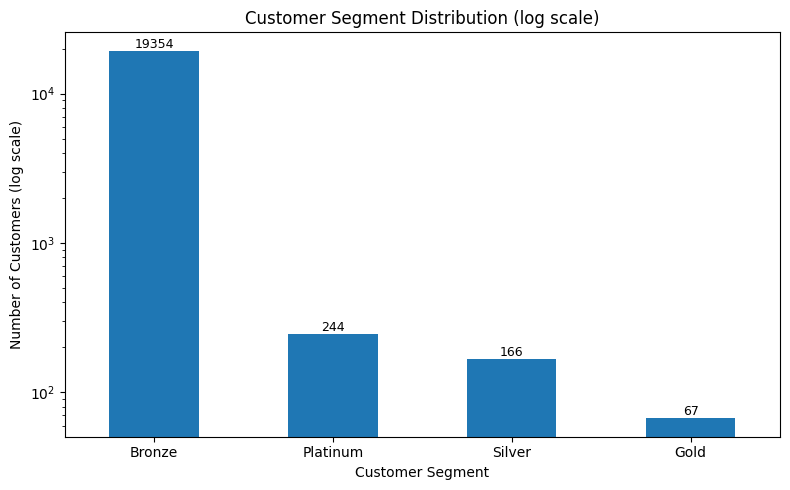

In [32]:
plt.figure(figsize=(8,5))

segment_counts = customer_segments["customer_segment"].value_counts()

ax = segment_counts.plot(kind="bar")
plt.yscale("log")
plt.title("Customer Segment Distribution (log scale)")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers (log scale)")
plt.xticks(rotation=0)

for i, v in enumerate(segment_counts):
    ax.text(i, v, str(v), ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig(f"{output_dir}/04_customer_segments.png", dpi=300, bbox_inches="tight")
plt.show()

### Business Insight:
Over 95% of customers fall into the Bronze segment, with very few reaching Silver, Gold, or Platinum tiers. This indicates the customer base is heavily weighted toward low-value, one-time or infrequent buyers, and there's a significant untapped opportunity to grow mid-tier customers into repeat, higher-value ones through loyalty or re-engagement campaigns.

## Visualization 5 — Category Performance

<Figure size 1000x500 with 0 Axes>

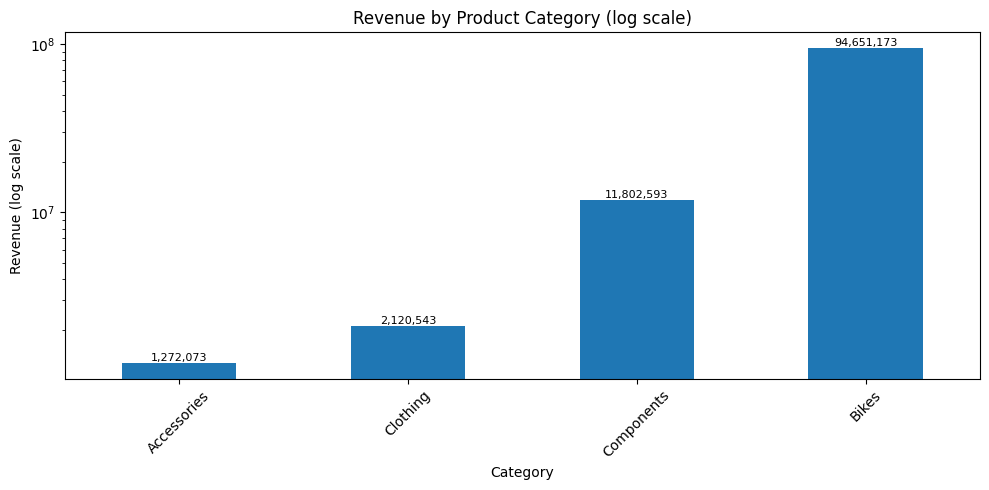

In [33]:
plt.figure(figsize=(10,5))

cat_data = category_performance.dropna(subset=["category"]).sort_values("revenue")

ax = cat_data.plot(
    x="category", y="revenue", kind="bar", figsize=(10,5), legend=False
)
plt.yscale("log")
plt.title("Revenue by Product Category (log scale)")
plt.xlabel("Category")
plt.ylabel("Revenue (log scale)")
plt.xticks(rotation=45)

for i, v in enumerate(cat_data["revenue"]):
    ax.text(i, v, f"{v:,.0f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig(f"{output_dir}/05_category_revenue.png", dpi=300, bbox_inches="tight")
plt.show()

### Business Insight:
Bikes generate roughly 8x more revenue than the next-largest category (Components), while Accessories and Clothing contribute comparatively little. This heavy reliance on a single category is a concentration risk — a slowdown in bike sales would disproportionately impact total revenue, so diversifying focus toward growing Accessories/Clothing could reduce this exposure. Additionally, a small number of products have no assigned category, which should be cleaned up in the product catalog.

## Visualization 6 — Product Performance

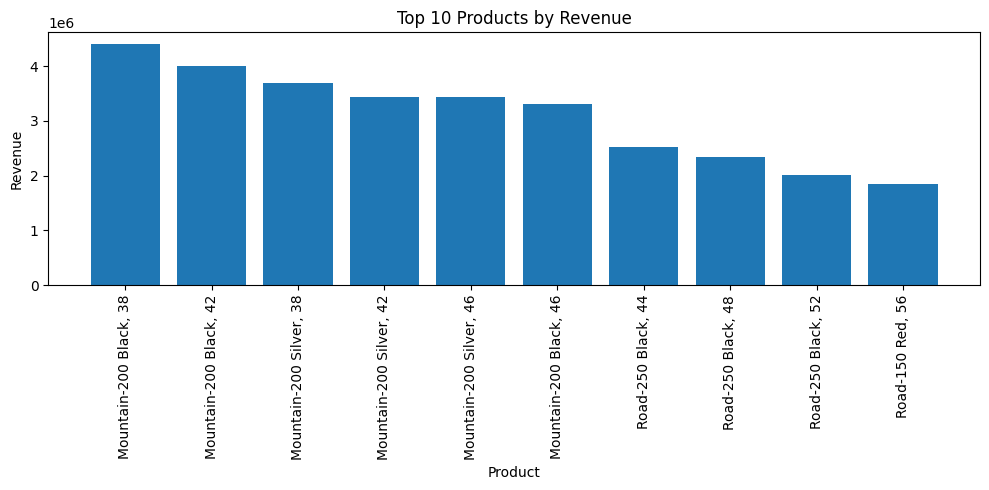

In [27]:
top_products = product_performance.sort_values("total_revenue", ascending=False).head(10)
plt.figure(figsize=(10,5))
plt.bar(top_products["product_name"], top_products["total_revenue"])
plt.title("Top 10 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig(f"{output_dir}/06_product_performance.png", dpi=300, bbox_inches="tight")
plt.show()

### Business Insight:
The top 6 of the top 10 products by revenue are all Mountain-200 variants (Black and Silver, across sizes 38–46), generating roughly $3.3M–$4.2M each — meaning a single product line dominates the best-seller list. Road-250 and Road-150 models trail behind at $1.8M–$2.5M. This heavy reliance on one product line is a concentration risk: if Mountain-200 demand drops (due to competition, seasonality, or supply issues), a large share of top-line revenue is exposed. Recommendation: monitor Mountain-200 inventory and lead times closely (cross-check against low_stock_products), and consider whether Road-series products are underpriced or under-marketed relative to their potential.

## Visualization 7 — Employee Performance

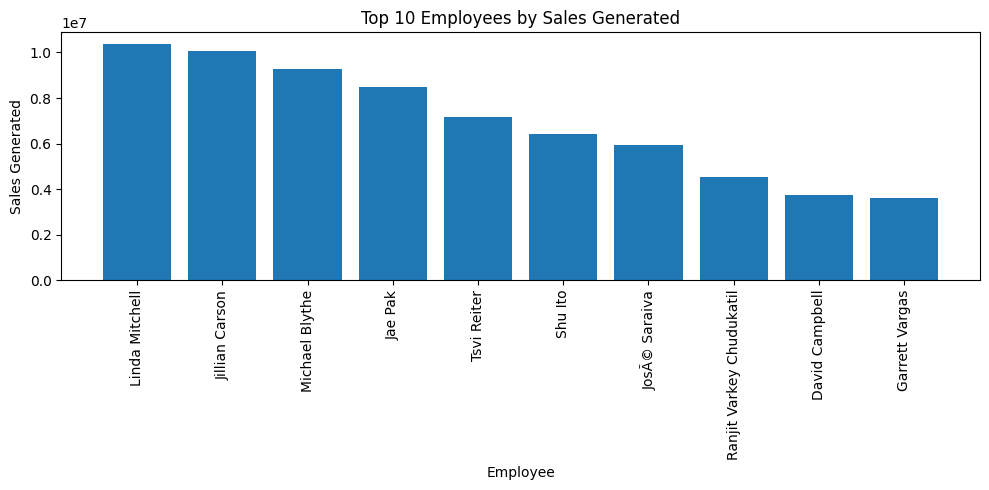

In [28]:
top_employees = employee_performance.sort_values("sales_generated", ascending=False).head(10)
plt.figure(figsize=(10,5))
plt.bar(top_employees["employee_name"], top_employees["sales_generated"])
plt.title("Top 10 Employees by Sales Generated")
plt.xlabel("Employee")
plt.ylabel("Sales Generated")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig(f"{output_dir}/07_employee_performance.png", dpi=300, bbox_inches="tight")
plt.show()

### Business Insight:
Linda Mitchell leads with roughly $10.2M in sales generated, only marginally ahead of Jillian Carson (~$9.9M) and Michael Blythe (~$9.1M) — the top 3 are tightly clustered. However, there's a steeper drop-off after position 4 (Jae Pak, ~$8.4M), with the #10 performer (Garrett Vargas) generating roughly $3.5M — less than half of the top performer's total. This suggests sales performance isn't evenly distributed: a small group of top performers is disproportionately responsible for revenue. Recommendation: study what top performers (Linda Mitchell, Jillian Carson, Michael Blythe) are doing differently — territory assignment, account size, or sales technique — and use it to coach or mentor lower-ranked employees rather than only rewarding the top tier.

## Visualization 8 — Inventory Status

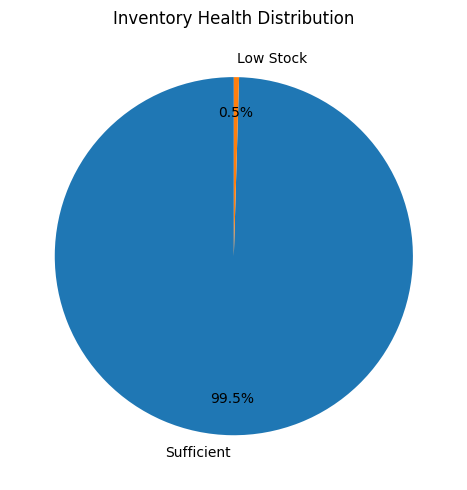

In [34]:
plt.figure(figsize=(8,5))

inventory_status["inventory_status"].value_counts().plot(
    kind="pie", autopct="%1.1f%%", startangle=90, pctdistance=0.8, labeldistance=1.1
)
plt.title("Inventory Health Distribution")
plt.ylabel("")
plt.tight_layout()
plt.savefig(f"{output_dir}/08_inventory_status.png", dpi=300, bbox_inches="tight")
plt.show()

### Business Insight:
Only 0.5% of products are currently flagged as "Low Stock," suggesting inventory is well-managed overall. However, since even a small number of stockouts on high-demand items (like Bikes, the top revenue category) can cause outsized revenue loss, it's worth cross-referencing the specific low-stock items against product_rankings to confirm none of them are top sellers.

## Visualization 9 — Executive KPI Summary

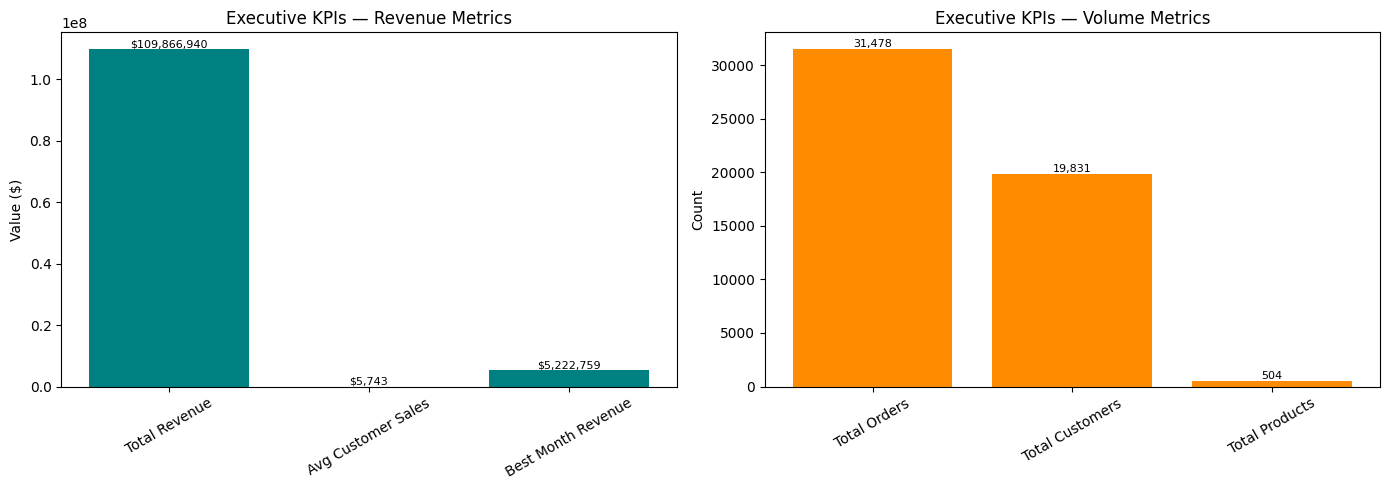

,total_revenue,total_orders,total_customers,total_products,avg_customer_sales,best_month_revenue
0,1.098669e+08,31478.0,19831,504,5743.175144,5.222759e+06


In [35]:
exec_kpi = pd.read_sql("SELECT * FROM analytics.exec_kpi_summary", engine)

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Left: monetary KPIs
money_labels = ["Total Revenue", "Avg Customer Sales", "Best Month Revenue"]
money_values = [
    exec_kpi["total_revenue"][0],
    exec_kpi["avg_customer_sales"][0],
    exec_kpi["best_month_revenue"][0],
]
axes[0].bar(money_labels, money_values, color="teal")
axes[0].set_title("Executive KPIs — Revenue Metrics")
axes[0].set_ylabel("Value ($)")
axes[0].tick_params(axis="x", rotation=30)
for i, v in enumerate(money_values):
    axes[0].text(i, v, f"${v:,.0f}", ha="center", va="bottom", fontsize=8)

# Right: count KPIs
count_labels = ["Total Orders", "Total Customers", "Total Products"]
count_values = [
    exec_kpi["total_orders"][0],
    exec_kpi["total_customers"][0],
    exec_kpi["total_products"][0],
]
axes[1].bar(count_labels, count_values, color="darkorange")
axes[1].set_title("Executive KPIs — Volume Metrics")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=30)
for i, v in enumerate(count_values):
    axes[1].text(i, v, f"{v:,.0f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig(f"{output_dir}/09_executive_kpi_summary.png", dpi=300, bbox_inches="tight")
plt.show()

exec_kpi

### Business Insight:
Total revenue is heavily concentrated relative to order and customer counts, meaning average order value is high. This is consistent with a bikes-driven, big-ticket sales model rather than high-frequency, low-cost purchasing — useful context for forecasting and cash flow planning.